# Extended Data Fig. 6 |  Global average annual rates of mangrove degradation and loss (2018-2023)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import palettable
from tqdm import tqdm
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot
from geemap import cartoee as cee
import geemap

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [3]:
os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
df_deforestation_annualrate = pd.read_csv('Code_Data/EstimatedAnnualChange/ByGrid_AnnualDeforestationRate_XGBoost.csv')
df_degradation_annualrate = pd.read_csv('Code_Data/EstimatedAnnualChange/ByGrid_AnnualDegradationRate_XGBoost.csv')

variable = 'meanrate'
df_deforestation_annualrate[variable] = 100*df_deforestation_annualrate[[str(i) for i in range(2018,2023)]].apply(np.nanmean, axis=1) #100 to convert to percentage
df_degradation_annualrate[variable] = 100*df_degradation_annualrate[[str(i) for i in range(2018,2023)]].apply(np.nanmean, axis=1)

gdf_grids = gpd.read_file('Code_Data/Grids_1degree.shp') # Read the grid shapefile
gdf_grids = gdf_grids[['ID','geometry']] # Select the columns we need
gdf_degradation = gdf_grids.merge(df_degradation_annualrate, left_on='ID', right_on='Region', how='left') # Join the degradation rate with the grid shapefile by the grid ID
gdf_degradation = gdf_degradation[gdf_degradation['ID'].isin(df_degradation_annualrate['Region'])] # Filter the grids which have degradation data

gdf_deforestation = gdf_grids.merge(df_deforestation_annualrate, left_on='ID', right_on='Region', how='left') # Join the deforestation rate with the grid shapefile by the grid ID
gdf_deforestation = gdf_deforestation[gdf_deforestation['ID'].isin(df_deforestation_annualrate['Region'])] # Filter the grids which have degradation data
gdf_deforestation

,ID,geometry,Region,1984,1985,1986,1987,1988,1989,1990,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,meanrate
1,1,"POLYGON ((147 -39, 147.0625 -39, 147.125 -39, ...",1.0,0.001325,0.001325,0.001325,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,"POLYGON ((173 -40, 173 -39, 173.0625 -39, 173....",2.0,0.006579,0.006579,0.006579,0.006579,0.006579,0.000000,0.000000,...,0.000000,0.199885,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,5,"POLYGON ((176 -40, 176 -39, 176.0625 -39, 176....",5.0,0.012285,0.012285,0.012285,0.012285,0.012285,0.000000,0.000000,...,0.000000,0.000000,0.235294,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,6,"POLYGON ((177 -40, 177 -39, 177.0625 -39, 177....",6.0,0.006589,0.006589,0.006589,0.006589,0.006589,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,9,"POLYGON ((144 -39, 144 -38, 144.0625 -38, 144....",9.0,0.000081,0.000081,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.010361,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,1800,"POLYGON ((-179 -18, -178 -18, -178 -19, -179 -...",1800.0,0.000074,0.000074,0.000074,0.000074,0.000074,0.000074,0.000074,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1800,1801,"POLYGON ((-175 -18, -174 -18, -174 -19, -175 -...",1801.0,0.000073,0.000073,0.000073,0.000073,0.000073,0.000073,0.000073,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1801,1802,"POLYGON ((-174 -18, -173 -18, -173 -19, -174 -...",1802.0,0.000021,0.000021,0.000021,0.000021,0.000021,0.000021,0.000021,...,0.000000,0.000675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1802,1803,"POLYGON ((-176 -21, -175 -21, -175 -22, -176 -...",1803.0,0.000080,0.000080,0.000080,0.000080,0.000080,0.000080,0.000080,...,0.003049,0.000000,0.000522,0.000695,0.001388,0.003302,0.000871,0.000871,0.000261,0.133887


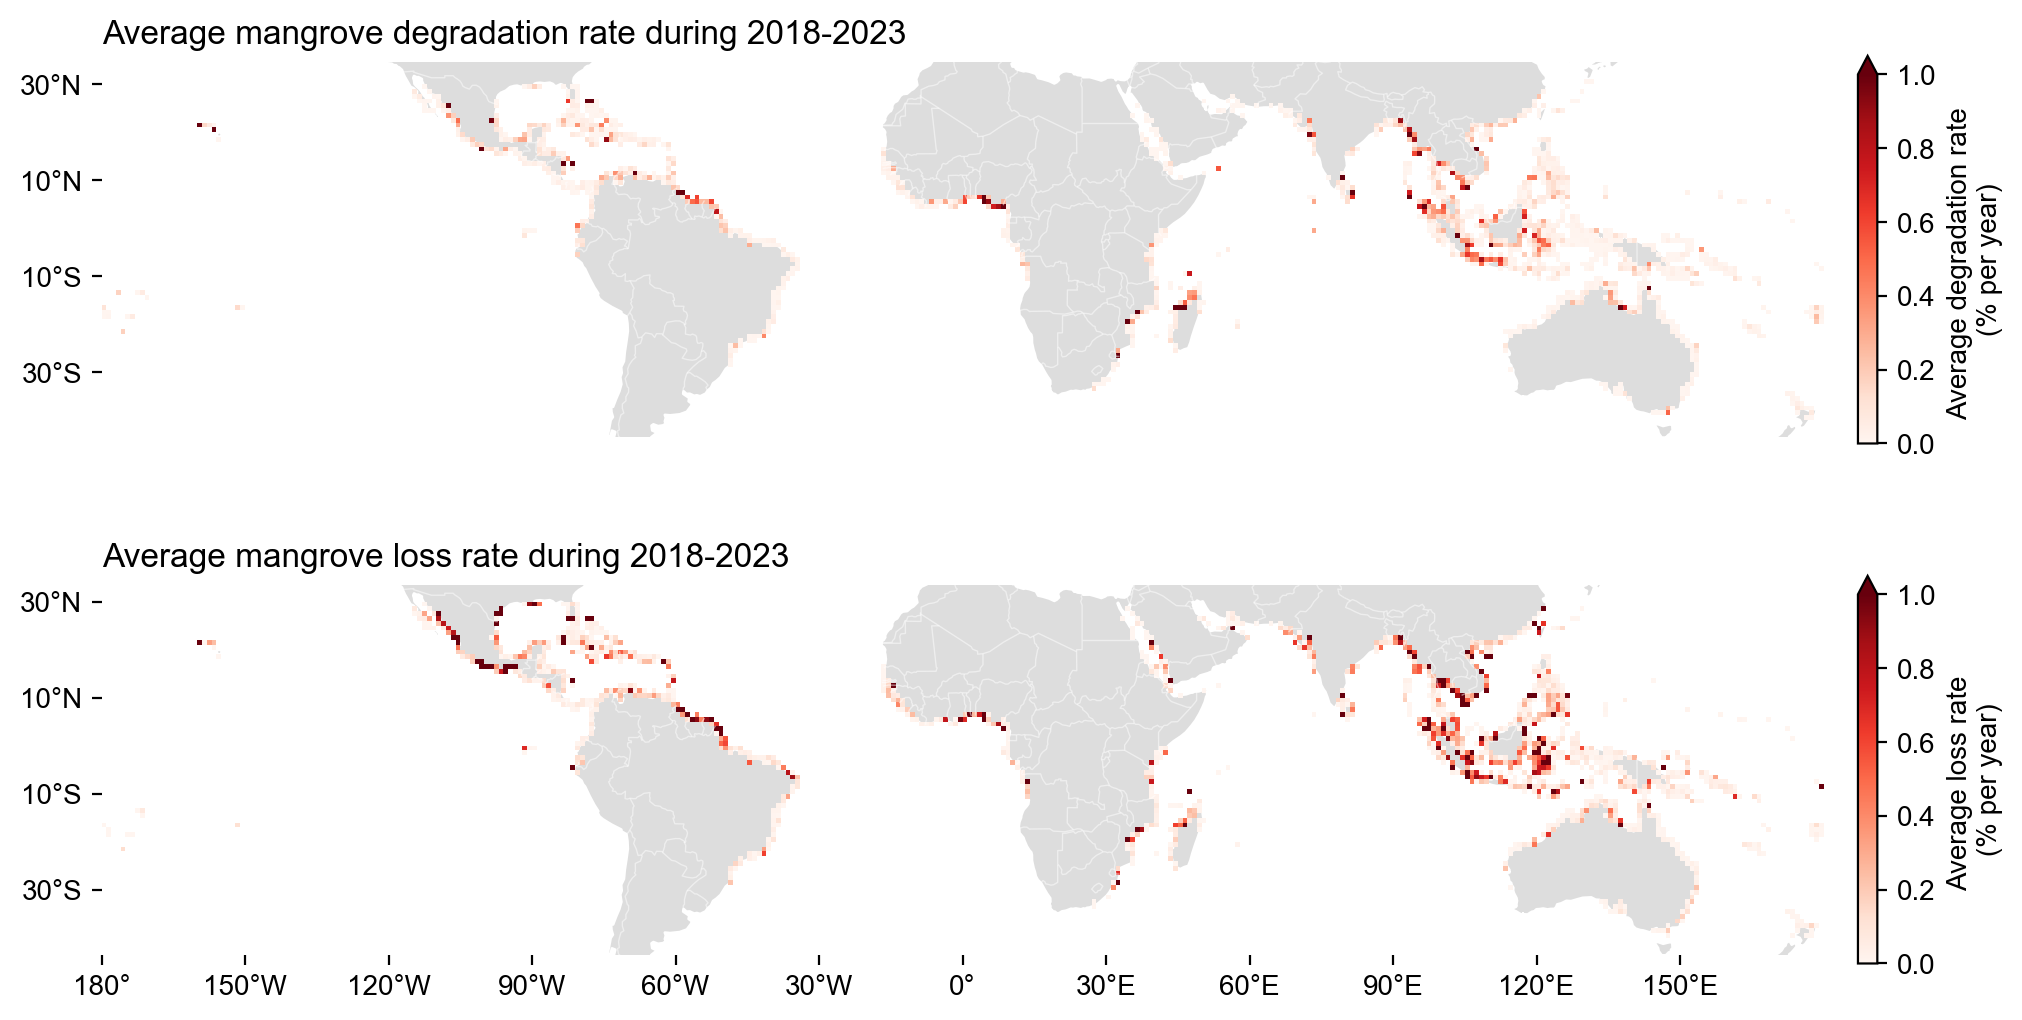

In [ ]:
fig = plt.figure(figsize=(10,5.2),constrained_layout=True)
gs = GridSpec(nrows=2, ncols=1,figure=fig)

ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_b = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
axs = [ax_a,ax_b]
gdfs = [gdf_degradation,gdf_deforestation]
titles = ['Average mangrove degradation rate during 2018-2023','Average mangrove loss rate during 2018-2023']
cb_labels = ["Average degradation rate \n(% per year)","Average loss rate \n(% per year)"]
for i,ax in enumerate(axs):
    ZhenPlot.add_basemap(ax,xticks=i,yticks=1,xrange=np.arange(-180,180,30),fontsize=12)
    ax.text(0,1.05,titles[i],fontdict={'size' : 12},color='black', transform=ax.transAxes)
    gdfs[i].plot(column=variable, ax=ax, cmap='Reds',edgecolor='None', legend=True, vmax=1,vmin=0,
              legend_kwds={'label': cb_labels[i],'orientation': "vertical",'extend':'max','shrink':0.77,'pad':0.02})
    ax.tick_params(axis='x',labelsize=10);ax.tick_params(axis='y',labelsize=10)
    ax.set_frame_on(False)

plt.savefig(r"Figures\MeanLossRate2018-2023.svg", dpi=500, format='svg', bbox_inches='tight')
plt.savefig(r"Figures\MeanLossRate2018-2023.png", dpi=500, format='png', bbox_inches='tight')